In [46]:
# Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew
import diptest
from statsmodels.graphics.gofplots import qqplot
from itertools import combinations
import joblib

In [47]:
# Load the data
df = pd.read_csv('../data/credit_card_cleaned.csv')

df.head()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
3,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.00,0,64,13500.0,6354.314328,198.065894,1.000000,12
4,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.00,0,12,2300.0,679.065082,532.033990,0.000000,12


In [48]:
# Normalize by Tenure
df['monthly_purchases'] = df['purchases'] / df['tenure']
df['monthly_oneoff_purchases'] = df['oneoff_purchases'] / df['tenure']
df['monthly_installments'] = df['installments_purchases'] / df['tenure']
df['monthly_cash_advance'] = df['cash_advance'] / df['tenure']
df['monthly_purchases_trx'] = df['purchases_trx'] / df['tenure']
df['monthly_cash_trx'] = df['cash_advance_trx'] / df['tenure']

In [49]:
# Credit and debt behavior 
df['credit_utilization'] = df['balance'] / df['credit_limit']

In [50]:
# Total monthly outgoings 
df['total_monthly_outgoings'] = df['monthly_purchases'] + df['monthly_cash_advance']

# Cash advance ratio
df['cash_advance_ratio'] = np.where(
    df['total_monthly_outgoings'] == 0,
    0,
    df['monthly_cash_advance'] / df['total_monthly_outgoings']
)

# One-off purchase share 
df['oneoff_share'] = np.where(
    df['purchases'] == 0,
    0,
    df['oneoff_purchases'] / df['purchases']
)

In [51]:
# Payment ratio
df['payment_to_minimum'] = df['payments'] / df['minimum_payments']

In [52]:
# Activity intensity 
df['total_monthly_trx'] = df['monthly_purchases_trx'] + df['monthly_cash_trx']

In [53]:
df.describe()

,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,...,monthly_installments,monthly_cash_advance,monthly_purchases_trx,monthly_cash_trx,credit_utilization,total_monthly_outgoings,cash_advance_ratio,oneoff_share,payment_to_minimum,total_monthly_trx
count,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,...,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000
mean,1251.611605,0.875645,1213.453730,725.598214,487.855516,921.904206,0.543731,0.237284,0.404538,0.120939,...,41.680318,81.512935,1.453019,0.262073,0.293934,185.020232,0.320180,0.400034,12.632723,1.715093
std,1848.266885,0.222835,2430.113827,1902.643290,997.800965,2209.561960,0.396307,0.320725,0.401551,0.197163,...,84.129356,196.497903,2.261155,0.635737,0.361002,275.894282,0.425857,0.420348,141.153747,2.307612
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000833,0.000000,0.000000,1.000372,0.000000
25%,89.940091,0.818182,100.000000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.166667,0.000000,0.028121,36.637500,0.000000,0.000000,1.799002,0.416667
50%,531.172145,1.000000,483.285000,94.000000,162.975000,0.000000,0.583333,0.083333,0.333333,0.000000,...,13.998333,0.000000,0.833333,0.000000,0.170298,99.034676,0.000000,0.248194,3.922387,1.000000
75%,1595.425526,1.000000,1378.970000,766.740000,581.312500,926.202924,1.000000,0.363636,0.833333,0.166667,...,50.000000,79.375376,1.750000,0.250000,0.499363,225.331308,0.821210,0.872330,8.455149,2.083333
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.000000,...,1875.000000,3928.100980,29.833333,10.250000,15.909951,4133.144740,1.000000,1.000000,6840.528861,29.833333


In [54]:
# Multimodality 
def multimodality_report(dataframe, features):
    results = []
    fig, axes = plt.subplots(nrows = len(features), ncols = 1, figsize = (8, 3 * len(features)))
    if len(features) == 1:
        axes = [axes]

    for ax, feat in zip(axes, features):
        series = dataframe[feat]

        # Dip test
        dip, pval = diptest.diptest(series)

        # Histogram
        sns.histplot(series, kde = True, ax = ax, bins = 30)
        ax.set_title(f'{feat}\nDip pvalue: {pval:.4f}')

        results.append({
            'feature': feat,
            'dip': dip,
            'pvalue': pval
        })

    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(results).sort_values('pvalue')

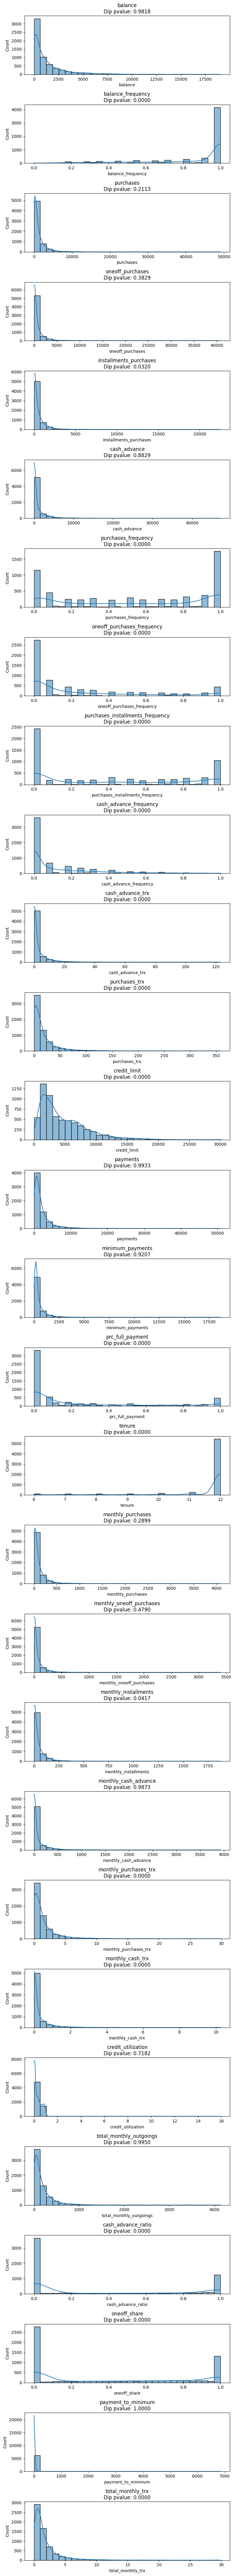

In [55]:
# Test the dip 
dip_df = multimodality_report(df, df.columns)

In [56]:
# Create the multimodal features with scores below 0.05
multimodal_features = dip_df[dip_df['pvalue'] < 0.05]['feature'].tolist()
print('Multimodal Features:', multimodal_features)

Multimodal Features: ['balance_frequency', 'oneoff_purchases_frequency', 'purchases_frequency', 'credit_limit', 'purchases_trx', 'cash_advance_trx', 'cash_advance_frequency', 'purchases_installments_frequency', 'prc_full_payment', 'monthly_cash_trx', 'total_monthly_trx', 'oneoff_share', 'cash_advance_ratio', 'tenure', 'monthly_purchases_trx', 'installments_purchases', 'monthly_installments']


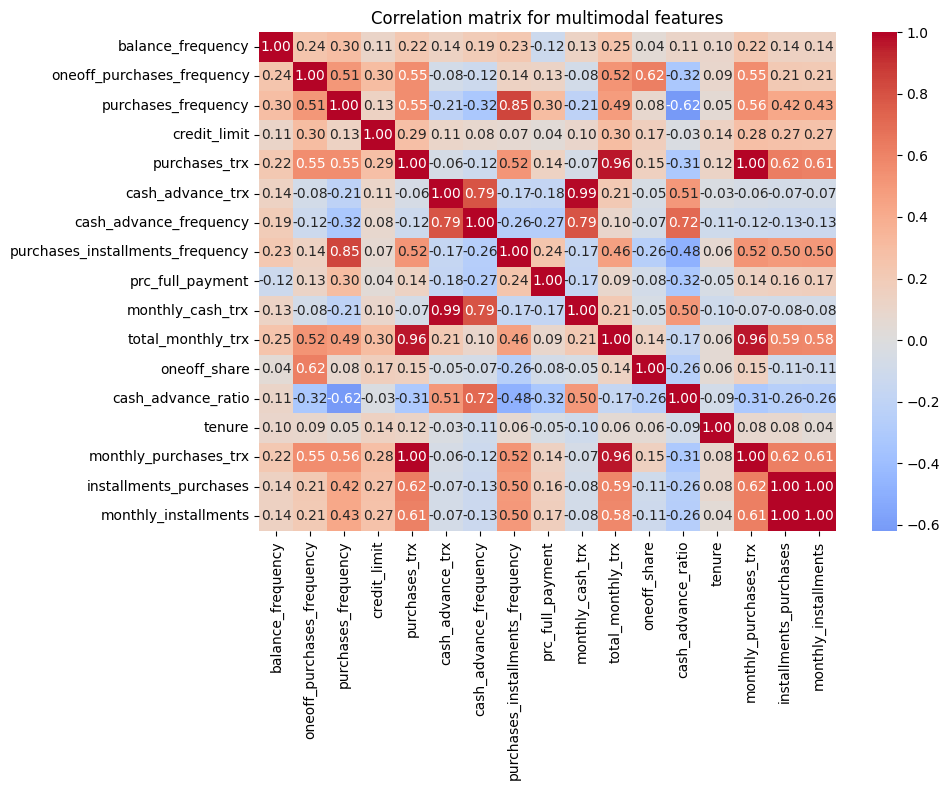

In [57]:
# Correlation filter
corr = df[multimodal_features].corr()
plt.figure(figsize = (10, 8))

sns.heatmap(
    corr, 
    annot = True,
    cmap = 'coolwarm',
    center = 0,
    fmt = '.2f'
)

plt.title('Correlation matrix for multimodal features')
plt.tight_layout()
plt.show()

Now we need to calculate the skew of these values and remove the ones in pairs with high corr.

In [58]:
# Compute the skewness 
skew_abs = df[multimodal_features].apply(lambda x: np.abs(skew(x))).sort_values()

In [59]:
# Correlation with more than 0.7
threshold  = 0.7
high_corr_pairs = []

for col1, col2 in combinations(multimodal_features, 2):
    if abs(corr.loc[col1, col2]) >= threshold:
        high_corr_pairs.append((col1, col2, corr.loc[col1, col2]))

for p in high_corr_pairs:
    print(f'{p[0]} - {p[1]}: {p[2]:.3f}')

purchases_frequency - purchases_installments_frequency: 0.845
purchases_trx - total_monthly_trx: 0.959
purchases_trx - monthly_purchases_trx: 0.998
cash_advance_trx - cash_advance_frequency: 0.793
cash_advance_trx - monthly_cash_trx: 0.986
cash_advance_frequency - monthly_cash_trx: 0.794
cash_advance_frequency - cash_advance_ratio: 0.715
total_monthly_trx - monthly_purchases_trx: 0.961
installments_purchases - monthly_installments: 0.997


Now we decide which ones to keep

In [60]:
def select_best_feature(group, dip_df, skew_abs):
    '''
    Given a list of features that are all correlated with each other,
    choose the ones with lowest dip pvalues,
    and if tied, choose the lowest absolute skewness.
    '''

    group_dip = dip_df[dip_df['feature'].isin(group)].set_index('feature')
    best = group_dip['pvalue'].idxmin()

    candidates = group_dip[group_dip['pvalue'] == group_dip.loc[best, 'pvalue']].index
    
    if len(candidates) > 1:
        best = skew_abs.loc[candidates].idxmin()

    return best

In [61]:
# build a ranked list
features_selected = multimodal_features.copy()

high_corr_pairs_sorted = sorted(high_corr_pairs, key = lambda x: -abs(x[2]))

dropped = set()

for feat1, feat2, corr_val in high_corr_pairs_sorted:
    if feat1 in dropped or feat2 in dropped:
        continue

    group = [feat1, feat2]

    best = select_best_feature(group, dip_df, skew_abs)

    if best == feat1:
        dropped.add(feat2)
    else:
        dropped.add(feat1)

features_after_corr = [f for f in features_selected if f not in dropped]
print('Features after correlation filtering:', features_after_corr)

Features after correlation filtering: ['balance_frequency', 'oneoff_purchases_frequency', 'purchases_frequency', 'credit_limit', 'prc_full_payment', 'total_monthly_trx', 'oneoff_share', 'cash_advance_ratio', 'tenure', 'installments_purchases']


purchases_frequency           0.154723
oneoff_share                  0.361403
cash_advance_ratio            0.739475
oneoff_purchases_frequency    1.284315
prc_full_payment              1.433774
credit_limit                  1.492517
balance_frequency             1.814524
tenure                        3.376387
total_monthly_trx             4.124205
installments_purchases        6.994011
dtype: float64


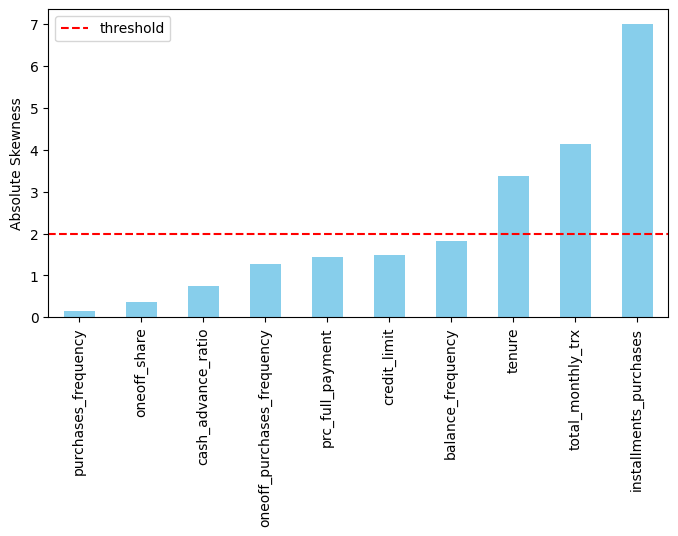

In [62]:
# Filter on the remaining skew
remaining_skew = df[features_after_corr].apply(lambda x: np.abs(skew(x))).sort_values()

print(remaining_skew)

plt.figure(figsize = (8, 4))

remaining_skew.plot(kind = 'bar', color = 'skyblue')
plt.axhline(y = 2, color = 'r', linestyle = '--', label = 'threshold')

plt.ylabel('Absolute Skewness')
plt.legend()
plt.show()

We are going to remove the ones with skew of above 2.

In [63]:
skew_threshold = 2
final_features = remaining_skew[remaining_skew <= skew_threshold].index.tolist()
print('Final Features:', final_features)

Final Features: ['purchases_frequency', 'oneoff_share', 'cash_advance_ratio', 'oneoff_purchases_frequency', 'prc_full_payment', 'credit_limit', 'balance_frequency']


In [64]:
# Scale the final features
df_final = df[final_features].copy()

scaler = StandardScaler()
df_final = pd.DataFrame(scaler.fit_transform(df_final), columns = df_final.columns)

df_final.head()

,purchases_frequency,oneoff_share,cash_advance_ratio,oneoff_purchases_frequency,prc_full_payment,credit_limit,balance_frequency
0,-0.951520,-0.951750,-0.751907,-0.739894,-0.654221,-0.996401,-0.257893
1,-1.372104,-0.951750,1.596484,-0.739894,0.025487,0.604512,0.150106
2,-1.161813,1.427420,-0.751907,-0.480047,-0.654221,-0.943038,0.558104
3,1.151393,1.196456,-0.751907,2.378288,2.404469,2.338834,0.558104
4,1.151393,-0.951750,-0.751907,-0.739894,-0.654221,-0.649537,0.558104


In [65]:
# Save the fitted scaler and the new model
#joblib.dump(scaler, '../model/scaler.pkl')

#df_final.to_csv('../data/credit_card_final.csv', index = False)